<a href="https://colab.research.google.com/github/morrita10305/stackblitz-starters-ie36qt/blob/main/ML_mid_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.tree import plot_tree

# 匯入處理不平衡數據與新模型的套件
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


from google.colab import drive
drive.mount('/content/drive')


train_path = '/content/drive/MyDrive/ML/Training Dataset.csv'
test_path = '/content/drive/MyDrive/ML/Test Dataset.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(train.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Ar

In [ ]:
# 數據預處理 (Data Preprocessing)
# ==========================================
# 處理缺失值 (使用眾數補齊類別型，中位數補齊數值型)
train['Gender'] = train['Gender'].fillna(train['Gender'].mode()[0])
train['Married'] = train['Married'].fillna(train['Married'].mode()[0])
train['Dependents'] = train['Dependents'].fillna(train['Dependents'].mode()[0])
train['Self_Employed'] = train['Self_Employed'].fillna(train['Self_Employed'].mode()[0])
train['Credit_History'] = train['Credit_History'].fillna(train['Credit_History'].mode()[0])
train['Loan_Amount_Term'] = train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0])
train['LoanAmount'] = train['LoanAmount'].fillna(train['LoanAmount'].median())

# 處理特殊字元 (Dependents 中的 '3+' 轉為數字 3)
train['Dependents'] = train['Dependents'].replace('3+', 3).astype(float)

# ==========================================
# 【新增】特徵工程 (Feature Engineering)
# ==========================================
# 1. 總收入 (Total Income): 將 ApplicantIncome + CoapplicantIncome 合併
train['Total_Income'] = train['ApplicantIncome'] + train['CoapplicantIncome']

# 2. 分期負擔比 (Debt-to-Income Ratio): 計算 LoanAmount 與總收入的比例
# 加上極小值 1e-5 避免除以零的情況
train['Debt_To_Income_Ratio'] = train['LoanAmount'] / (train['Total_Income'] + 1e-5)

print("\n--- 完成特徵工程 ---")
print("新增特徵：Total_Income (總收入), Debt_To_Income_Ratio (分期負擔比)")

# 特徵編碼 (Label Encoding: 將文字轉為數字)
le = LabelEncoder()
categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in categorical_cols:
    train[col] = le.fit_transform(train[col])

# 定義特徵 (X) 與 目標變數 (y)
# 移除 Loan_ID 因為它只是序號，對預測沒有幫助
X = train.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = train['Loan_Status']

# 切分數據：80% 訓練，20% 驗證
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 【新增】解決數據不平衡 (Handling Data Imbalance)
# ==========================================
print("\n--- 執行 SMOTE 處理數據不平衡 ---")
print(f"SMOTE 前，訓練集中的目標變數分佈：\n{y_train.value_counts()}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"SMOTE 後，訓練集中的目標變數分佈：\n{y_train_resampled.value_counts()}")

# ==========================================
# 【新增】超參數調優 (Hyperparameter Tuning)
# ==========================================
print("\n--- 進行 Random Forest 超參數調優 (GridSearchCV) ---")
# 設定要測試的參數網格
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None]
}

rf = RandomForestClassifier(random_state=42)
# 使用 GridSearchCV 找出最佳參數
grid_search = GridSearchCV(estimator=rf, param_grid=rf_param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_resampled, y_train_resampled)

best_rf = grid_search.best_estimator_
print(f"最佳 Random Forest 參數: {grid_search.best_params_}")




--- 完成特徵工程 ---
新增特徵：Total_Income (總收入), Debt_To_Income_Ratio (分期負擔比)

--- 執行 SMOTE 處理數據不平衡 ---
SMOTE 前，訓練集中的目標變數分佈：
Loan_Status
1    342
0    149
Name: count, dtype: int64
SMOTE 後，訓練集中的目標變數分佈：
Loan_Status
0    342
1    342
Name: count, dtype: int64

--- 進行 Random Forest 超參數調優 (GridSearchCV) ---
最佳 Random Forest 參數: {'max_depth': None, 'n_estimators': 200}


In [ ]:
print('--- 重新檢查處理缺失值後結果 ---')
print(train.isnull().sum())

--- 重新檢查處理缺失值後結果 ---
Loan_ID                 0
Gender                  0
Married                 0
Dependents              0
Education               0
Self_Employed           0
ApplicantIncome         0
CoapplicantIncome       0
LoanAmount              0
Loan_Amount_Term        0
Credit_History          0
Property_Area           0
Loan_Status             0
Total_Income            0
Debt_To_Income_Ratio    0
dtype: int64



--- 訓練 Logistic Regression 與 XGBoost 進行對比 ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:44:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



========== Random Forest (Tuned + SMOTE) 評估結果 ==========
驗證集準確率 (Accuracy): 0.7805
分類報告 (可觀察 Recall 與 F1-Score):
              precision    recall  f1-score   support

           0       0.75      0.56      0.64        43
           1       0.79      0.90      0.84        80

    accuracy                           0.78       123
   macro avg       0.77      0.73      0.74       123
weighted avg       0.78      0.78      0.77       123


========== Logistic Regression (SMOTE) 評估結果 ==========
驗證集準確率 (Accuracy): 0.7886
分類報告 (可觀察 Recall 與 F1-Score):
              precision    recall  f1-score   support

           0       0.90      0.44      0.59        43
           1       0.76      0.97      0.86        80

    accuracy                           0.79       123
   macro avg       0.83      0.71      0.73       123
weighted avg       0.81      0.79      0.77       123


========== XGBoost (SMOTE) 評估結果 ==========
驗證集準確率 (Accuracy): 0.7886
分類報告 (可觀察 Recall 與 F1-Score):
              precis

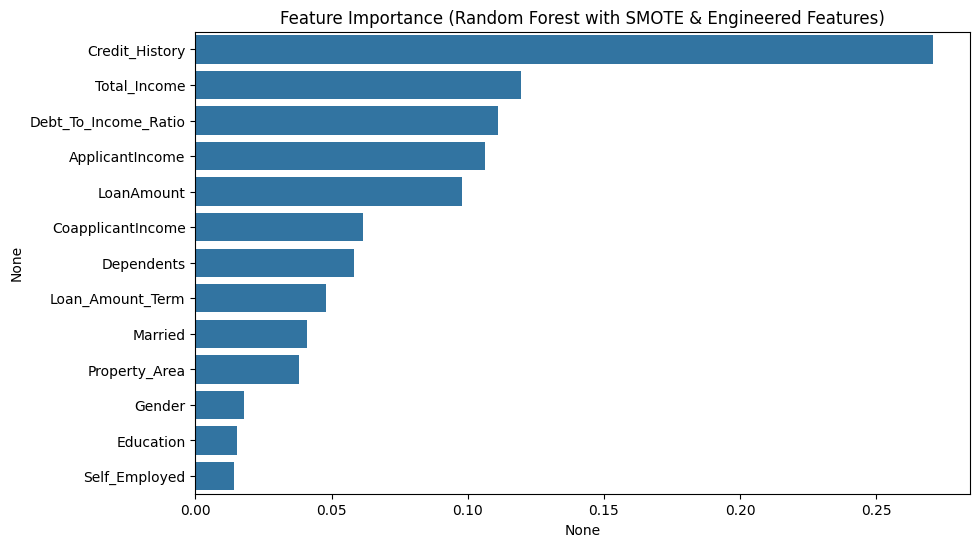

In [ ]:
# ==========================================
# 【新增】模型對比 (Model Comparison)
# ==========================================
print("\n--- 訓練 Logistic Regression 與 XGBoost 進行對比 ---")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)

# 評估與對比模型
models = {
    'Random Forest (Tuned + SMOTE)': best_rf,
    'Logistic Regression (SMOTE)': lr_model,
    'XGBoost (SMOTE)': xgb_model
}

for name, model in models.items():
    y_pred = model.predict(X_val)
    print(f"\n========== {name} 評估結果 ==========")
    print(f"驗證集準確率 (Accuracy): {accuracy_score(y_val, y_pred):.4f}")
    print("分類報告 (可觀察 Recall 與 F1-Score):")
    print(classification_report(y_val, y_pred))

# ==========================================
# 【新增】模型對比與 Auditing 討論
# ==========================================
print("\n--- 模型 Auditing 與公平性討論 ---")
importance = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importance, y=importance.index)
plt.title("Feature Importance (Random Forest with SMOTE & Engineered Features)")
plt.show()


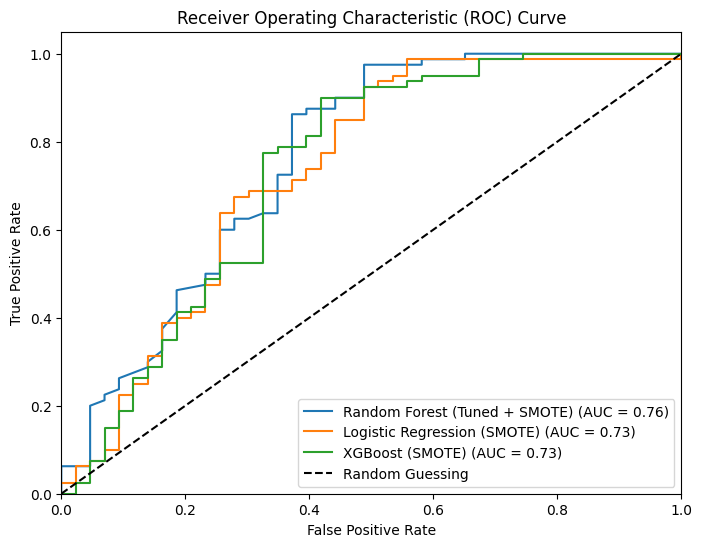

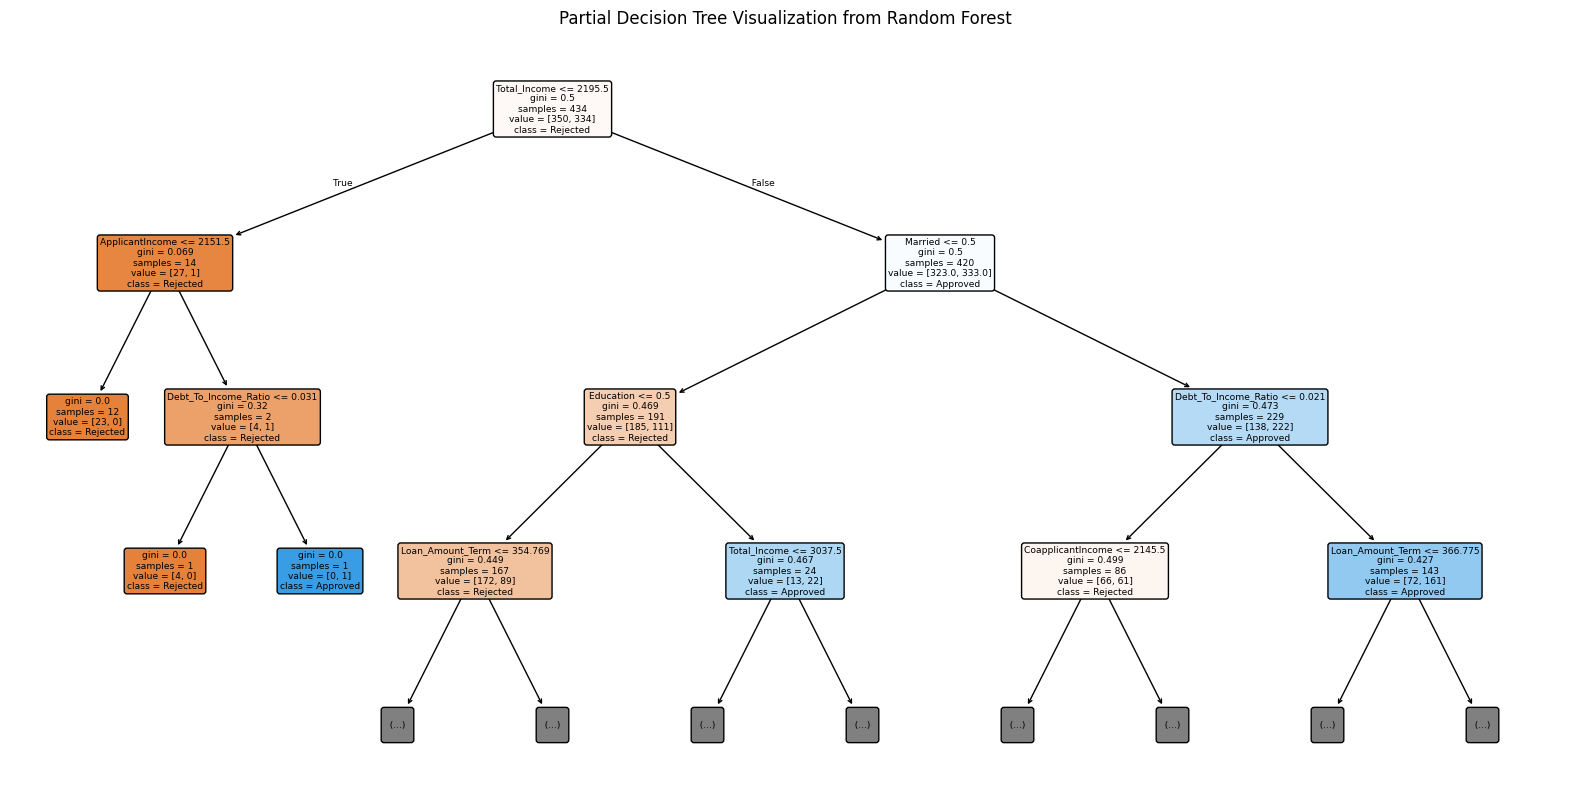

NameError: name 'test_processed' is not defined

In [ ]:
# ==========================================
# 【新增】進階視覺化圖表 (Advanced Visualizations)
# ==========================================

# 1. ROC 曲線與 AUC 分數
plt.figure(figsize=(8,6))

for name, model in models.items():
    # 取得預測為 1 (核准) 的機率
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)[:, 1]
    else:
        y_prob = model.predict(X_val)

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# 2. 決策樹圖 (Partial Decision Tree)
# 從隨機森林中抽出一棵樹來視覺化，限制 max_depth=3 以保持圖表清晰可讀
plt.figure(figsize=(20,10))
plot_tree(best_rf.estimators_[0],
          feature_names=X.columns,
          class_names=['Rejected', 'Approved'],
          filled=True,
          rounded=True,
          max_depth=3)
plt.title("Partial Decision Tree Visualization from Random Forest")
plt.show()


In [ ]:
# ==========================================
# 【新增】實測階段 (Real Test: Final Prediction)
# ==========================================

# --- 對 Test Dataset 進行與訓練集相同的預處理 ---

# 1. 保存 Loan_ID
test_ids = test['Loan_ID']

# 2. 處理缺失值 (使用訓練集的眾數或中位數補齊)
test['Gender'] = test['Gender'].fillna(train['Gender'].mode()[0])
test['Married'] = test['Married'].fillna(train['Married'].mode()[0])
test['Dependents'] = test['Dependents'].fillna(train['Dependents'].mode()[0])
test['Self_Employed'] = test['Self_Employed'].fillna(train['Self_Employed'].mode()[0])
test['Credit_History'] = test['Credit_History'].fillna(train['Credit_History'].mode()[0])
test['Loan_Amount_Term'] = test['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0])
test['LoanAmount'] = test['LoanAmount'].fillna(train['LoanAmount'].median())

# 3. 處理特殊字元 (Dependents 中的 '3+' 轉為數字 3)
test['Dependents'] = test['Dependents'].replace('3+', 3).astype(float)

# 4. 特徵工程 (與訓練集相同)
test['Total_Income'] = test['ApplicantIncome'] + test['CoapplicantIncome']
test['Debt_To_Income_Ratio'] = test['LoanAmount'] / (test['Total_Income'] + 1e-5)

# 5. 特徵編碼 (Label Encoding: 將文字轉為數字)
# 使用訓練集處理時定義的 categorical_cols，但不包含 'Loan_Status'
categorical_cols_for_encoding = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

for col in categorical_cols_for_encoding:
    if col in test.columns:
        le_temp = LabelEncoder()
        # 為了確保訓練集和測試集的編碼一致，將所有可能的類別合併後再 fit
        # 並確保轉換前的數據類型為字符串，以避免可能發生的錯誤
        all_categories = pd.concat([train[col], test[col]], axis=0).astype(str).unique()
        le_temp.fit(all_categories)
        test[col] = le_temp.transform(test[col].astype(str))

# 6. 選擇與訓練集相同的特徵列，並確保順序一致
# X 是訓練集處理後的特徵列表
feature_cols = X.columns
test_processed = test[feature_cols]


# 1. 對 Test Dataset 進行預測
# 確保 test_data 已經過與訓練集相同的預處理 (Label Encoding, Missing Values)
test_predictions = best_rf.predict(test_processed)

# 2. 轉換回原始標籤 (將 0, 1 轉回 N, Y)
test_labels = ["Y" if p == 1 else "N" for p in test_predictions]

# 3. 建立輸出結果表格
submission = pd.DataFrame({
    'Loan_ID': test_ids,  # 原本讀取測試集時保留的 ID
    'Loan_Status': test_labels
})

# 4. 展示實測結果前五筆
print("========== Real Test: Final Prediction Results (First 5 rows) ==========")
print(submission.head())


========== Real Test: Final Prediction Results (First 5 rows) ==========
    Loan_ID Loan_Status
0  LP001015           Y
1  LP001022           Y
2  LP001031           Y
3  LP001035           Y
4  LP001051           Y
